Dados carregados com sucesso!
   cod_pedido regiao_pais                       produto  valor  quantidade  \
0       50284       Norte  Biscoito  True Champion 300g  24.64         2.0   
1       50285       Norte  Biscoito  True Champion 300g  23.52         2.0   
2       50286       Norte  Biscoito  True Champion 300g  24.64         4.0   
3       50287       Norte  Biscoito  True Champion 300g  21.28         4.0   
4       50288       Norte  Biscoito  True Champion 300g  24.64         NaN   

   valor_total_bruto       data     estado      formapagto  \
0              49.28 2020-03-12       Acre  Cartão Crédito   
1              47.04 2020-04-10      Amapá  Cartão Crédito   
2              98.56 2020-08-07       Pará        Dinheiro   
3              85.12 2020-01-10   Rondônia             Pix   
4              49.28 2020-04-11  Tocantins  Cartão Crédito   

  centro_distribuicao responsavelpedido  valor_comissao  lucro_liquido  \
0          Rapid Pink            Carlos            1.7

<ipython-input-22-812883440ca8>:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  features.fillna(method='ffill', inplace=True)
<ipython-input-22-812883440ca8>:49: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  targets.fillna(method='ffill', inplace=True)
<ipython-input-22-812883440ca8>:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  targets.fillna(method='ffill', inplace=True)
<ipython-input-22-812883440ca8>:52: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  features[col] = features[col].view('int64')
/usr/local/lib/python3.11/dis

Epoch 1/50
5626/5626 ━━━━━━━━━━━━━━━━━━━━ 180s 31ms/step - loss: 0.0304 - val_loss: 0.0019
Epoch 2/50
5626/5626 ━━━━━━━━━━━━━━━━━━━━ 202s 31ms/step - loss: 0.0031 - val_loss: 5.3775e-04
Epoch 3/50
5626/5626 ━━━━━━━━━━━━━━━━━━━━ 179s 32ms/step - loss: 0.0020 - val_loss: 2.8450e-04
Epoch 4/50
5626/5626 ━━━━━━━━━━━━━━━━━━━━ 178s 32ms/step - loss: 0.0013 - val_loss: 2.5041e-04
Epoch 5/50
5626/5626 ━━━━━━━━━━━━━━━━━━━━ 181s 32ms/step - loss: 0.0012 - val_loss: 0.0024
Epoch 6/50
5626/5626 ━━━━━━━━━━━━━━━━━━━━ 180s 32ms/step - loss: 0.0013 - val_loss: 2.4406e-04
Epoch 7/50
5626/5626 ━━━━━━━━━━━━━━━━━━━━ 187s 33ms/step - loss: 8.3075e-04 - val_loss: 3.1121e-04
Epoch 8/50
5626/5626 ━━━━━━━━━━━━━━━━━━━━ 195s 32ms/step - loss: 7.7034e-04 - val_loss: 4.1044e-04
Epoch 9/50
5626/5626 ━━━━━━━━━━━━━━━━━━━━ 197s 31ms/step - loss: 7.9275e-04 - val_loss: 1.9912e-04
Epoch 10/50
5626/5626 ━━━━━━━━━━━━━━━━━━━━ 218s 34ms/step - loss: 8.7284e-04 - val_loss: 2.2592e-04
Epoch 11/50
5626/5626 ━━━━━━━━━━━━━━━━━━━

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

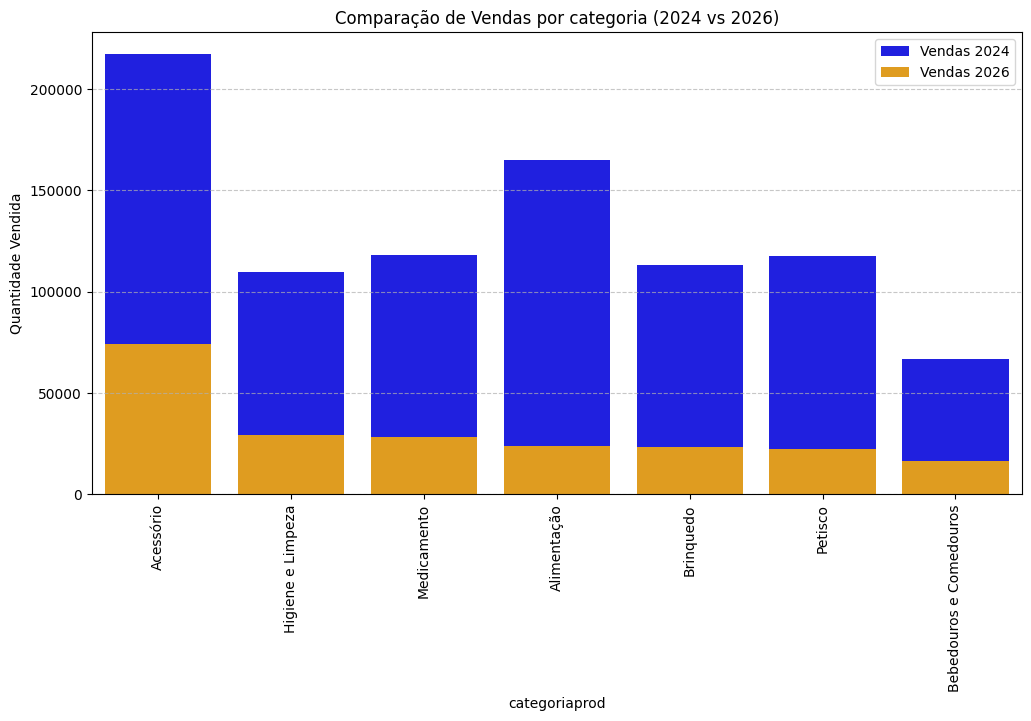

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import openpyxl
import os

label_encoders = {}

def carregar_dados(caminho_arquivo):
    try:
        dados = pd.read_excel(caminho_arquivo, engine='openpyxl', sheet_name='Planilha1')
        print("Dados carregados com sucesso!")
        print(dados.head())
        return dados
    except Exception as e:
        print(f'Erro ao carregar os dados: {e}')
        raise

def tratar_colunas_categoricas(dados, colunas_categoricas):
    global label_encoders
    for coluna in colunas_categoricas:
        if coluna in dados.columns:
            le = LabelEncoder()
            dados[coluna] = le.fit_transform(dados[coluna])
            label_encoders[coluna] = le  # Salva o LabelEncoder
    return dados


def preparar_dados(dados, lookback, target_cols):
    scaler_features = MinMaxScaler()
    scaler_targets = MinMaxScaler()

    colunas_categoricas = ['regiao_pais', 'produto', 'estado', 'formapagto',
                           'centro_distribuicao', 'responsavelpedido', 'categoriaprod']
    dados = tratar_colunas_categoricas(dados, colunas_categoricas)

    features = dados.drop(columns=target_cols)
    targets = dados[target_cols]

    features.fillna(method='ffill', inplace=True)
    targets.fillna(method='ffill', inplace=True)

    for col in features.select_dtypes(include=['datetime64']).columns:
        features[col] = features[col].view('int64')

    features_normalizados = scaler_features.fit_transform(features)
    targets_normalizados = scaler_targets.fit_transform(targets)

    X, y = [], []
    for i in range(lookback, len(features_normalizados)):
        X.append(features_normalizados[i - lookback:i, :])
        y.append(targets_normalizados[i, :])

    return np.array(X), np.array(y), scaler_features, scaler_targets


def dividir_dados(X, y, train_size=0.8):
    split_idx = int(len(X) * train_size)
    return X[:split_idx], X[split_idx:], y[:split_idx], y[split_idx:]

# Função para criar o modelo LSTM
def criar_modelo_lstm(input_shape, output_size):
    model = Sequential([
        LSTM(units=50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=output_size)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


def treinar_modelo(model, X_train, y_train, epochs=50, batch_size=32):
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    return model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                     validation_split=0.1, verbose=1, callbacks=[early_stopping])


def fazer_previsao(model, X_test, scaler_targets):
    previsoes_normalizadas = model.predict(X_test)
    return scaler_targets.inverse_transform(previsoes_normalizadas)


caminho_arquivo = "/vendas_linha_petshop_2020_2024.xlsx"
lookback = 30
target_cols = ["quantidade", "categoriaprod"]

dados = carregar_dados(caminho_arquivo)
X, y, scaler_features, scaler_targets = preparar_dados(dados, lookback, target_cols)
X_train, X_test, y_train, y_test = dividir_dados(X, y)

modelo = criar_modelo_lstm((X_train.shape[1], X_train.shape[2]), y_train.shape[1])
historico = treinar_modelo(modelo, X_train, y_train, epochs=50, batch_size=32)

previsoes = fazer_previsao(modelo, X_test, scaler_targets)

df_previsoes_2026 = pd.DataFrame(previsoes, columns=target_cols)

# Reverter valores numéricos para as categorias
if "categoriaprod" in df_previsoes_2026.columns:
    le_categoria  = label_encoders.get("categoriaprod")
    if le_categoria:
        df_previsoes_2026["categoriaprod"] = le_categoria.inverse_transform(
            df_previsoes_2026["categoriaprod"].astype(int)
        )


if "categoriaprod" in dados.columns:
    le_categoria = label_encoders.get("categoriaprod")
    if le_categoria:
        dados["categoriaprod"] = le_categoria.inverse_transform(
            dados["categoriaprod"].astype(int)
        )


df_previsoes_2026.to_excel("previsoes_vendas_2026.xlsx", index=False)
print("Previsões para 2026 salvas com sucesso!")


from google.colab import files
files.download("previsoes_vendas_2026.xlsx")

# Comparação de vendas por categoria em 2024 vs 2026
df_vendas_2024 = dados.groupby("categoriaprod")["quantidade"].sum().reset_index()
df_vendas_2026 = df_previsoes_2026.groupby("categoriaprod")["quantidade"].sum().reset_index()

df_vendas_2024.rename(columns={"quantidade": "vendas_2024"}, inplace=True)
df_vendas_2026.rename(columns={"quantidade": "vendas_2026"}, inplace=True)

df_vendas_2024["categoriaprod"] = df_vendas_2024["categoriaprod"].astype(str)
df_vendas_2026["categoriaprod"] = df_vendas_2026["categoriaprod"].astype(str)

df_comparacao = pd.merge(df_vendas_2024, df_vendas_2026, on="categoriaprod", how="outer").fillna(0)

plt.figure(figsize=(12, 6))
df_comparacao = df_comparacao.sort_values(by="vendas_2026", ascending=False)  # Ordena para melhor visualização
ax = sns.barplot(x="categoriaprod", y="vendas_2024", data=df_comparacao, color="blue", label="Vendas 2024")
sns.barplot(x="categoriaprod", y="vendas_2026", data=df_comparacao, color="orange", label="Vendas 2025")

plt.xticks(rotation=90)
plt.xlabel("categoriaprod")
plt.ylabel("Quantidade Vendida")
plt.title("Comparação de Vendas por categoria (2024 vs 2025)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()
